<a href="https://colab.research.google.com/github/Ketan19-hue/java/blob/main/hospitalreadmisson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset created!
Shape: (2000, 12)

Missing values:
 age                 0
heart_rate          0
systolic_bp         0
glucose             0
prior_admissions    0
prior_er_visits     0
length_of_stay      0
diabetes            0
heart_failure       0
kidney_disease      0
copd                0
readmitted_30d      0
dtype: int64

Readmission rate (% of patients readmitted within 30 days):
readmitted_30d
0    90.2
1     9.8
Name: proportion, dtype: float64


/tmp/ipykernel_871/750820674.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='readmitted_30d', data=df, ax=axes[0], palette='Set2')
/tmp/ipykernel_871/750820674.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Not Readmitted (0)', 'Readmitted (1)'])
/tmp/ipykernel_871/750820674.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='readmitted_30d', y='prior_admissions', data=df, ax=axes[1], palette='Set2')


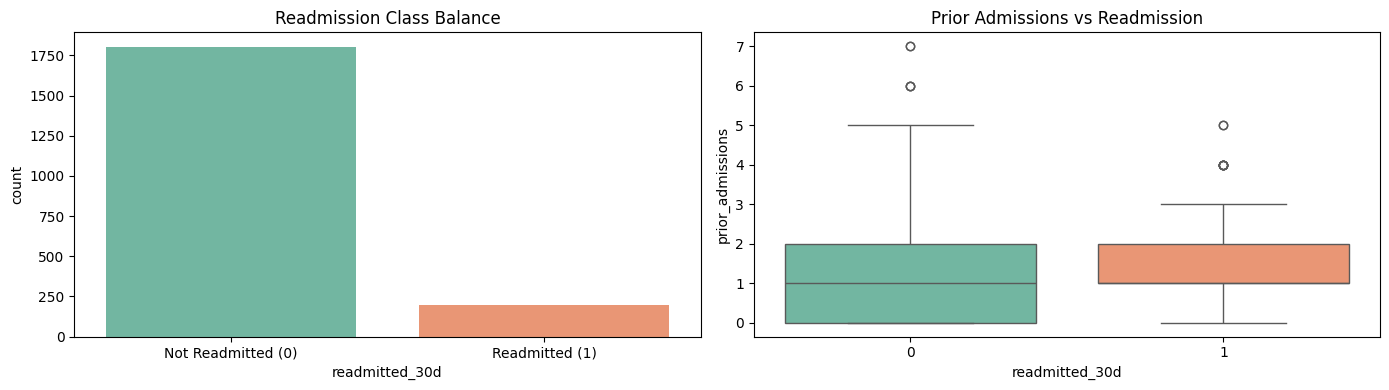

X shape: (2000, 11)
y shape: (2000,)
Training set size: 1600
Testing set size: 400
Model trained successfully!
ROC-AUC Score: 0.728


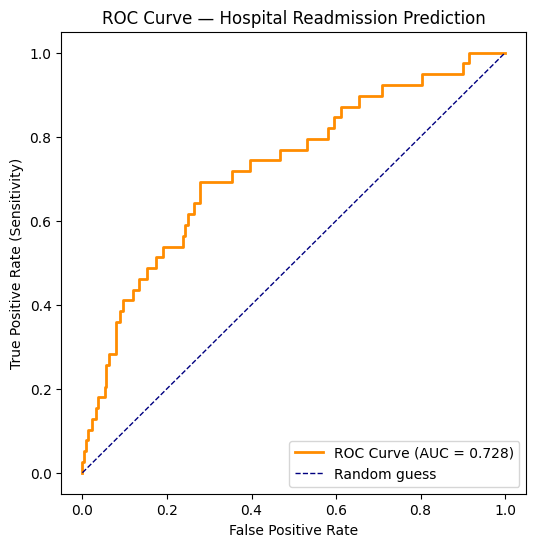

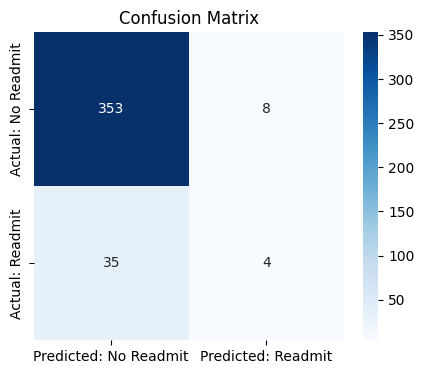

              precision    recall  f1-score   support

  No Readmit       0.91      0.98      0.94       361
     Readmit       0.33      0.10      0.16        39

    accuracy                           0.89       400
   macro avg       0.62      0.54      0.55       400
weighted avg       0.85      0.89      0.87       400

Confusion Matrix at threshold = 0.3:
[[341  20]
 [ 30   9]]

              precision    recall  f1-score   support

  No Readmit       0.92      0.94      0.93       361
     Readmit       0.31      0.23      0.26        39

    accuracy                           0.88       400
   macro avg       0.61      0.59      0.60       400
weighted avg       0.86      0.88      0.87       400


Compare: at threshold=0.5, False Negatives = 35 | False Positives = 8
At threshold=0.3, False Negatives = 30 | False Positives = 20


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, precision_recall_curve
)

np.random.seed(42)

n_patients = 2000

age = np.random.normal(60, 15, n_patients).clip(18, 95)
heart_rate = np.random.normal(80, 12, n_patients).clip(50, 140)
systolic_bp = np.random.normal(130, 20, n_patients).clip(80, 200)
glucose = np.random.normal(110, 35, n_patients).clip(60, 300)

prior_admissions = np.random.poisson(1.2, n_patients)
prior_er_visits = np.random.poisson(0.8, n_patients)
length_of_stay = np.random.poisson(4, n_patients).clip(1, 30)

diabetes = np.random.binomial(1, 0.30, n_patients)
heart_failure = np.random.binomial(1, 0.20, n_patients)
kidney_disease = np.random.binomial(1, 0.15, n_patients)
copd = np.random.binomial(1, 0.18, n_patients)

# Build a 'risk score' that realistically drives readmission probability
risk_score = (
    0.03 * (age - 60)
    + 0.35 * prior_admissions
    + 0.25 * prior_er_visits
    + 0.10 * length_of_stay
    + 0.8 * diabetes
    + 1.1 * heart_failure
    + 0.9 * kidney_disease
    + 0.7 * copd
    + 0.02 * (glucose - 110)
    - 4.5  # baseline offset so overall readmission rate is realistic (~20-25%)
)

prob_readmit = 1 / (1 + np.exp(-risk_score))  # logistic function
readmitted_30d = np.random.binomial(1, prob_readmit)

df = pd.DataFrame({
    'age': age.round(0),
    'heart_rate': heart_rate.round(0),
    'systolic_bp': systolic_bp.round(0),
    'glucose': glucose.round(0),
    'prior_admissions': prior_admissions,
    'prior_er_visits': prior_er_visits,
    'length_of_stay': length_of_stay,
    'diabetes': diabetes,
    'heart_failure': heart_failure,
    'kidney_disease': kidney_disease,
    'copd': copd,
    'readmitted_30d': readmitted_30d
})

print("Dataset created!")
df.head()

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nReadmission rate (% of patients readmitted within 30 days):")
print(df['readmitted_30d'].value_counts(normalize=True) * 100)

df.describe()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(x='readmitted_30d', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Readmission Class Balance')
axes[0].set_xticklabels(['Not Readmitted (0)', 'Readmitted (1)'])

sns.boxplot(x='readmitted_30d', y='prior_admissions', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Prior Admissions vs Readmission')

plt.tight_layout()
plt.show()

X = df.drop(columns=['readmitted_30d'])
y = df['readmitted_30d']

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coef_df

y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  # probability of readmission
y_pred = model.predict(X_test_scaled)         # 0/1 prediction at 0.5 threshold

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted_Probability': y_pred_proba.round(3),
    'Predicted_Class': y_pred
})
results.head(10)

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {auc_score:.3f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve — Hospital Readmission Prediction')
plt.legend(loc='lower right')
plt.show()

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No Readmit', 'Predicted: Readmit'],
            yticklabels=['Actual: No Readmit', 'Actual: Readmit'])
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred, target_names=['No Readmit', 'Readmit']))

threshold = 0.3
y_pred_lower_threshold = (y_pred_proba >= threshold).astype(int)

cm_lower = confusion_matrix(y_test, y_pred_lower_threshold)

print(f"Confusion Matrix at threshold = {threshold}:")
print(cm_lower)
print()
print(classification_report(y_test, y_pred_lower_threshold, target_names=['No Readmit', 'Readmit']))

print("\nCompare: at threshold=0.5, False Negatives =", cm[1][0], "| False Positives =", cm[0][1])
print(f"At threshold={threshold}, False Negatives =", cm_lower[1][0], "| False Positives =", cm_lower[0][1])



